# PB2 KNMI Preprocessing and Weather Correlation Analysis


It completes the work for:

- **PB2-01 Extend and Finalize KNMI Dataset**
- **PB2-02 Investigate correlations between weather parameters and wind conditions**

The notebook loads all KNMI text files, combines files belonging to the same weather station, trims the data to **2015 and after**, cleans KNMI special values, converts units, handles missing values using suitable interpolation/filling, saves the final preprocessed dataset, and creates correlation/visualization outputs.

In [21]:
# Imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 1. Locate the raw KNMI files

Because this notebook is inside the `preprocessing` folder, the raw KNMI files are expected one folder up in:

```text
../datasets_raw/KNMI
```

The code below also includes fallbacks in case you run the notebook from the project root or from another folder.

In [22]:
# Find project root and KNMI raw data folder automatically
cwd = Path.cwd()

possible_data_dirs = [
    cwd.parent / "datasets_raw" / "KNMI",   # when notebook is inside preprocessing/
    cwd / "datasets_raw" / "KNMI",          # when notebook is run from project root
    cwd / "KNMI",                            # when notebook is inside datasets_raw/
    cwd,                                     # when notebook is directly inside the txt folder
]

DATA_DIR = None
for path in possible_data_dirs:
    if path.exists() and list(path.glob("*.txt")):
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find KNMI .txt files. Expected them in ../datasets_raw/KNMI or datasets_raw/KNMI. "
        f"Current working directory is: {cwd}"
    )

PROJECT_ROOT = DATA_DIR.parent.parent if DATA_DIR.name == "KNMI" else cwd
OUTPUT_DIR = PROJECT_ROOT / "datasets_processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "PB2_KNMI"
STATION_OUTPUT_DIR = OUTPUT_DIR / "KNMI_by_station_2015plus"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
STATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(DATA_DIR.glob("*.txt"))

print("Current working directory:", cwd)
print("Using KNMI data folder:", DATA_DIR)
print(f"Found {len(files)} KNMI text files")
for f in files:
    print("-", f.name)

Current working directory: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\preprocessing
Using KNMI data folder: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\datasets_raw\KNMI
Found 15 KNMI text files
- De Kooy_235_2011-2020.txt
- De Kooy_235_2021-2030.txt
- Hoek van Holland_330_2011-2020.txt
- Hoek van Holland_330_2021-2030.txt
- Hoorn_251_2011-2020.txt
- Hoorn_251_2021-2030.txt
- Lauwersoog_277_2011-2020.txt
- Lauwersoog_277_2021-2030.txt
- Valkenburg_210_2011-2020.txt
- Vlieland_242_2011-2020.txt
- Vlieland_242_2021-2030.txt
- Vlissingen_310_2011-2020.txt
- Vlissingen_310_2021-2030.txt
- Wilhelminadorp_323_2011-2020.txt
- Wilhelminadorp_323_2021-2030.txt


## 2. Read KNMI text files

KNMI hourly files contain metadata first, then the actual table starts at the line beginning with:

```text
# STN,YYYYMMDD,HH,...
```

The loader below automatically finds that header line, reads the data table, and extracts the station name, station number, and period from the filename.

In [23]:
def extract_station_info(path: Path):
    """Extract station name, station number, and period from filenames like 'De Kooy_235_2011-2020.txt'."""
    name = path.stem
    name = re.sub(r"\(\d+\)$", "", name).strip()  # remove endings like (1)

    match = re.match(r"(.+?)_(\d+)_(\d{4}-\d{4})", name)
    if match:
        station_name = match.group(1).strip()
        station_id = int(match.group(2))
        period = match.group(3)
        return station_name, station_id, period

    # fallback if filename format is different
    return name, np.nan, ""


def read_knmi_file(path: Path) -> pd.DataFrame:
    """Read one KNMI hourly txt file into a clean dataframe with metadata columns."""
    header_idx = None
    header_line = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            if line.lstrip().startswith("# STN") or line.lstrip().startswith("#STN"):
                header_idx = i
                header_line = line
                break

    if header_idx is None:
        raise ValueError(f"Could not find KNMI data header in {path.name}")

    columns = [c.strip() for c in header_line.lstrip("#").strip().split(",")]

    df = pd.read_csv(
        path,
        skiprows=header_idx + 1,
        names=columns,
        sep=",",
        skipinitialspace=True,
        na_values=["", " ", "   ", "NaN"],
        engine="python"
    )

    df.columns = df.columns.str.strip()

    station_name, station_id, period = extract_station_info(path)
    df["Station"] = station_name
    df["Station_ID"] = station_id
    df["Source_Period"] = period
    df["Source_File"] = path.name

    return df

raw_parts = []

for file in files:
    df_part = read_knmi_file(file)
    raw_parts.append(df_part)
    print(f"Loaded {file.name}: {df_part.shape[0]:,} rows")

raw = pd.concat(raw_parts, ignore_index=True)
print("\nCombined raw shape:", raw.shape)
raw.head()

Loaded De Kooy_235_2011-2020.txt: 87,672 rows
Loaded De Kooy_235_2021-2030.txt: 47,472 rows
Loaded Hoek van Holland_330_2011-2020.txt: 87,672 rows
Loaded Hoek van Holland_330_2021-2030.txt: 47,496 rows
Loaded Hoorn_251_2011-2020.txt: 87,672 rows
Loaded Hoorn_251_2021-2030.txt: 47,472 rows
Loaded Lauwersoog_277_2011-2020.txt: 87,672 rows
Loaded Lauwersoog_277_2021-2030.txt: 47,472 rows
Loaded Valkenburg_210_2011-2020.txt: 46,776 rows
Loaded Vlieland_242_2011-2020.txt: 87,672 rows
Loaded Vlieland_242_2021-2030.txt: 47,472 rows
Loaded Vlissingen_310_2011-2020.txt: 87,672 rows
Loaded Vlissingen_310_2021-2030.txt: 47,472 rows
Loaded Wilhelminadorp_323_2011-2020.txt: 53,784 rows
Loaded Wilhelminadorp_323_2021-2030.txt: 47,472 rows

Combined raw shape: (958920, 29)


,STN,YYYYMMDD,HH,DD,FH,FF,FX,T,T10N,TD,SQ,Q,DR,RH,P,VV,N,U,WW,IX,M,R,S,O,Y,Station,Station_ID,Source_Period,Source_File
0,235,20110101,1,260.0,70.0,70.0,100.0,51.0,NaN,43.0,0.0,0.0,0.0,0.0,10205.0,57.0,8.0,95.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,De Kooy,235,2011-2020,De Kooy_235_2011-2020.txt
1,235,20110101,2,260.0,70.0,70.0,100.0,50.0,NaN,41.0,0.0,0.0,0.0,0.0,10201.0,56.0,8.0,94.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,De Kooy,235,2011-2020,De Kooy_235_2011-2020.txt
2,235,20110101,3,270.0,70.0,50.0,100.0,50.0,NaN,41.0,0.0,0.0,0.0,0.0,10199.0,58.0,8.0,94.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,De Kooy,235,2011-2020,De Kooy_235_2011-2020.txt
3,235,20110101,4,270.0,60.0,60.0,80.0,51.0,NaN,41.0,0.0,0.0,0.0,0.0,10196.0,56.0,8.0,93.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,De Kooy,235,2011-2020,De Kooy_235_2011-2020.txt
4,235,20110101,5,270.0,60.0,50.0,80.0,50.0,NaN,41.0,0.0,0.0,0.0,0.0,10193.0,36.0,8.0,94.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,De Kooy,235,2011-2020,De Kooy_235_2011-2020.txt


## 3. Create timestamp and combine split station files

Some stations have multiple files, for example `2011-2020` and `2021-2030`. After loading, all files from the same station are combined into one continuous station dataset.

KNMI uses `YYYYMMDD` and `HH`. For hourly data, `HH = 1` represents the first hour of the day, so the timestamp is created as:

```python
YYYYMMDD + (HH - 1) hours
```

In [24]:
# Convert date/hour columns
raw["YYYYMMDD"] = pd.to_numeric(raw["YYYYMMDD"], errors="coerce")
raw["HH"] = pd.to_numeric(raw["HH"], errors="coerce")

# Drop rows that do not have a valid date or hour
raw = raw.dropna(subset=["YYYYMMDD", "HH"]).copy()
raw["YYYYMMDD"] = raw["YYYYMMDD"].astype(int).astype(str)
raw["HH"] = raw["HH"].astype(int)

# Create timestamp
base_date = pd.to_datetime(raw["YYYYMMDD"], format="%Y%m%d", errors="coerce")
raw["timestamp"] = base_date + pd.to_timedelta(raw["HH"] - 1, unit="h")

# Drop invalid timestamps
raw = raw.dropna(subset=["timestamp"]).copy()

# Sort and combine split files belonging to the same station
raw = raw.sort_values(["Station_ID", "Station", "timestamp"]).reset_index(drop=True)

# Remove duplicate station-timestamp rows if overlapping files exist
before_dupes = len(raw)
raw = raw.drop_duplicates(subset=["Station_ID", "timestamp"], keep="last").copy()
after_dupes = len(raw)

print(f"Removed duplicate station-timestamp rows: {before_dupes - after_dupes:,}")
print("Date range before trimming:", raw["timestamp"].min(), "to", raw["timestamp"].max())
print("Rows before trimming:", len(raw))

raw.groupby(["Station", "Station_ID"])["timestamp"].agg(["min", "max", "count"])

Removed duplicate station-timestamp rows: 0
Date range before trimming: 2011-01-01 00:00:00 to 2026-06-02 23:00:00
Rows before trimming: 958920


,,min,max,count
Station,Station_ID,,,
De Kooy,235,2011-01-01,2026-06-01 23:00:00,135144
Hoek van Holland,330,2011-01-01,2026-06-02 23:00:00,135168
Hoorn,251,2011-01-01,2026-06-01 23:00:00,135144
Lauwersoog,277,2011-01-01,2026-06-01 23:00:00,135144
Valkenburg,210,2011-01-01,2016-05-02 23:00:00,46776
Vlieland,242,2011-01-01,2026-06-01 23:00:00,135144
Vlissingen,310,2011-01-01,2026-06-01 23:00:00,135144
Wilhelminadorp,323,2011-01-01,2026-06-01 23:00:00,101256


## 4. Trim dataset to 2015 and after

For this backlog, older data is not needed. The dataset is trimmed to start from **2015-01-01**.

In [25]:
START_DATE = "2015-01-01"

knmi = raw[raw["timestamp"] >= START_DATE].copy()
knmi = knmi.sort_values(["Station_ID", "timestamp"]).reset_index(drop=True)

print("Date range after trimming:", knmi["timestamp"].min(), "to", knmi["timestamp"].max())
print("Rows after trimming:", len(knmi))

station_ranges = knmi.groupby(["Station", "Station_ID"])["timestamp"].agg(["min", "max", "count"])
display(station_ranges)

Date range after trimming: 2015-01-01 00:00:00 to 2026-06-02 23:00:00
Rows after trimming: 686424


,,min,max,count
Station,Station_ID,,,
De Kooy,235,2015-01-01,2026-06-01 23:00:00,100080
Hoek van Holland,330,2015-01-01,2026-06-02 23:00:00,100104
Hoorn,251,2015-01-01,2026-06-01 23:00:00,100080
Lauwersoog,277,2015-01-01,2026-06-01 23:00:00,100080
Valkenburg,210,2015-01-01,2016-05-02 23:00:00,11712
Vlieland,242,2015-01-01,2026-06-01 23:00:00,100080
Vlissingen,310,2015-01-01,2026-06-01 23:00:00,100080
Wilhelminadorp,323,2017-12-13,2026-06-01 23:00:00,74208


## 5. Convert columns to numeric and check available weather variables

The KNMI files contain more than wind data. They also include temperature, pressure, humidity, cloud cover, radiation, rainfall, visibility, and weather indicators where available.

In [26]:
# Columns expected in KNMI hourly weather data
expected_weather_cols = [
    "DD", "FH", "FF", "FX",       # wind direction, wind speed, gusts
    "T", "T10N", "TD",            # temperature variables
    "SQ", "Q",                    # sunshine and radiation
    "DR", "RH",                   # precipitation duration and amount
    "P", "VV", "N", "U",         # pressure, visibility, cloud cover, humidity
    "WW", "IX", "M", "R", "S", "O", "Y"  # weather codes / indicators
]

available_cols = [col for col in expected_weather_cols if col in knmi.columns]
print("Available weather columns:")
print(available_cols)

# Convert weather columns to numeric
for col in available_cols:
    knmi[col] = pd.to_numeric(knmi[col], errors="coerce")

# Quick availability check
availability = pd.DataFrame({
    "column": available_cols,
    "non_missing_rows": [knmi[col].notna().sum() for col in available_cols],
    "missing_pct": [knmi[col].isna().mean() * 100 for col in available_cols]
}).sort_values("missing_pct")

display(availability)

Available weather columns:
['DD', 'FH', 'FF', 'FX', 'T', 'T10N', 'TD', 'SQ', 'Q', 'DR', 'RH', 'P', 'VV', 'N', 'U', 'WW', 'IX', 'M', 'R', 'S', 'O', 'Y']


,column,non_missing_rows,missing_pct
4,T,685550,0.127327
6,TD,685423,0.145828
14,U,685423,0.145828
0,DD,685011,0.205849
2,FF,684962,0.212988
3,FX,684960,0.213279
1,FH,684959,0.213425
7,SQ,586231,14.596372
10,RH,586231,14.596372
8,Q,586231,14.596372


## 6. Clean KNMI special values and convert units

KNMI stores several measurements in tenths:

| Variable | Original KNMI unit | Converted unit |
|---|---:|---:|
| FH, FF, FX | 0.1 m/s | m/s |
| T, T10N, TD | 0.1 °C | °C |
| P | 0.1 hPa | hPa |
| RH | 0.1 mm | mm |
| DR | 0.1 hour | hour |
| SQ | 0.1 hour | hour |

Special KNMI values are also cleaned:

- `RH = -1` means less than 0.05 mm precipitation, so it is treated as 0.
- `SQ = -1` means less than 0.05 hours sunshine, so it is treated as 0.
- `DD = 990` means variable wind direction, so it is treated as missing for direction analysis.

In [27]:
# Clean special values BEFORE unit conversion
if "RH" in knmi.columns:
    knmi["RH"] = knmi["RH"].replace(-1, 0)

if "SQ" in knmi.columns:
    knmi["SQ"] = knmi["SQ"].replace(-1, 0)

if "DD" in knmi.columns:
    knmi["DD"] = knmi["DD"].replace(990, np.nan)

# Convert units from KNMI tenths to normal units
wind_cols = [c for c in ["FH", "FF", "FX"] if c in knmi.columns]
temp_cols = [c for c in ["T", "T10N", "TD"] if c in knmi.columns]

for col in wind_cols:
    knmi[col] = knmi[col] / 10

for col in temp_cols:
    knmi[col] = knmi[col] / 10

if "P" in knmi.columns:
    knmi["P"] = knmi["P"] / 10

if "RH" in knmi.columns:
    knmi["RH"] = knmi["RH"] / 10

if "DR" in knmi.columns:
    knmi["DR"] = knmi["DR"] / 10

if "SQ" in knmi.columns:
    knmi["SQ"] = knmi["SQ"] / 10

# Rename important columns to clearer names while keeping original KNMI codes useful
rename_map = {
    "DD": "wind_direction_deg",
    "FH": "wind_speed_ms",
    "FF": "wind_speed_10min_ms",
    "FX": "wind_gust_ms",
    "T": "temperature_c",
    "T10N": "min_temp_10cm_c",
    "TD": "dew_point_c",
    "SQ": "sunshine_duration_h",
    "Q": "global_radiation_j_cm2",
    "DR": "precip_duration_h",
    "RH": "precipitation_mm",
    "P": "pressure_hpa",
    "VV": "visibility_code",
    "N": "cloud_cover_octants",
    "U": "humidity_pct"
}

knmi = knmi.rename(columns={k: v for k, v in rename_map.items() if k in knmi.columns})

print("Columns after cleaning/renaming:")
print(knmi.columns.tolist())
knmi.head()

Columns after cleaning/renaming:
['STN', 'YYYYMMDD', 'HH', 'wind_direction_deg', 'wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms', 'temperature_c', 'min_temp_10cm_c', 'dew_point_c', 'sunshine_duration_h', 'global_radiation_j_cm2', 'precip_duration_h', 'precipitation_mm', 'pressure_hpa', 'visibility_code', 'cloud_cover_octants', 'humidity_pct', 'WW', 'IX', 'M', 'R', 'S', 'O', 'Y', 'Station', 'Station_ID', 'Source_Period', 'Source_File', 'timestamp']


,STN,YYYYMMDD,HH,wind_direction_deg,wind_speed_ms,wind_speed_10min_ms,wind_gust_ms,temperature_c,min_temp_10cm_c,dew_point_c,sunshine_duration_h,global_radiation_j_cm2,precip_duration_h,precipitation_mm,pressure_hpa,visibility_code,cloud_cover_octants,humidity_pct,WW,IX,M,R,S,O,Y,Station,Station_ID,Source_Period,Source_File,timestamp
0,210,20150101,1,210.0,4.0,5.0,7.0,3.2,NaN,1.2,0.0,0.0,0.0,0.0,1033.7,37.0,0.0,87.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,2015-01-01 00:00:00
1,210,20150101,2,210.0,4.0,5.0,8.0,3.0,NaN,0.8,0.0,0.0,0.0,0.0,1033.5,57.0,0.0,85.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,2015-01-01 01:00:00
2,210,20150101,3,200.0,5.0,4.0,8.0,2.6,NaN,0.4,0.0,0.0,0.0,0.0,1032.9,60.0,0.0,85.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,2015-01-01 02:00:00
3,210,20150101,4,210.0,4.0,4.0,7.0,2.7,NaN,0.5,0.0,0.0,0.0,0.0,1033.9,61.0,0.0,85.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,2015-01-01 03:00:00
4,210,20150101,5,190.0,5.0,6.0,8.0,2.2,NaN,0.5,0.0,0.0,0.0,0.0,1032.9,60.0,2.0,88.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,2015-01-01 04:00:00


## 7. Missing value report before interpolation

Before filling missing data, the notebook calculates missing percentages per variable. This gives evidence for the preprocessing decisions in PB2-01.

In [28]:
important_cols = [
    "wind_direction_deg",
    "wind_speed_ms",
    "wind_speed_10min_ms",
    "wind_gust_ms",
    "temperature_c",
    "min_temp_10cm_c",
    "dew_point_c",
    "sunshine_duration_h",
    "global_radiation_j_cm2",
    "precip_duration_h",
    "precipitation_mm",
    "pressure_hpa",
    "visibility_code",
    "cloud_cover_octants",
    "humidity_pct"
]

important_cols = [c for c in important_cols if c in knmi.columns]

missing_before = (
    knmi[important_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_before.columns = ["variable", "missing_pct_before"]

display(missing_before)

missing_before.to_csv(OUTPUT_DIR / "knmi_missing_values_before_interpolation.csv", index=False)
print("Saved missing value report before interpolation")

,variable,missing_pct_before
0,min_temp_10cm_c,83.364072
1,cloud_cover_octants,56.218897
2,visibility_code,41.721152
3,pressure_hpa,14.738704
4,sunshine_duration_h,14.596372
5,precip_duration_h,14.596372
6,precipitation_mm,14.596372
7,global_radiation_j_cm2,14.596372
8,wind_direction_deg,0.464145
9,wind_speed_ms,0.213425


Saved missing value report before interpolation


## 8. Interpolate and fill missing values properly

Different weather variables are handled differently:

- **Continuous variables** such as wind speed, temperature, pressure, humidity, radiation, and dew point are interpolated over time within each station.
- **Wind direction** is circular, so it is not interpolated directly. Instead, it is converted into sine/cosine components, interpolated, and then reconstructed.
- **Cloud cover** is discrete, so it is forward/backward filled and rounded.
- **Precipitation** missing values are filled with 0 after KNMI trace-rain values are cleaned.

In [29]:
# Create circular wind direction components before interpolation
if "wind_direction_deg" in knmi.columns:
    direction = knmi["wind_direction_deg"].copy()

    # If wind speed is 0, direction is not meaningful
    if "wind_speed_ms" in knmi.columns:
        direction = direction.mask(knmi["wind_speed_ms"] == 0, np.nan)

    radians = np.deg2rad(direction)
    knmi["wind_dir_sin"] = np.sin(radians)
    knmi["wind_dir_cos"] = np.cos(radians)

# Variables suitable for time interpolation
continuous_cols = [
    "wind_speed_ms",
    "wind_speed_10min_ms",
    "wind_gust_ms",
    "temperature_c",
    "min_temp_10cm_c",
    "dew_point_c",
    "sunshine_duration_h",
    "global_radiation_j_cm2",
    "pressure_hpa",
    "humidity_pct",
    "visibility_code",
    "wind_dir_sin",
    "wind_dir_cos"
]
continuous_cols = [c for c in continuous_cols if c in knmi.columns]

# Variables that should not be smoothly interpolated
precip_cols = [c for c in ["precipitation_mm", "precip_duration_h"] if c in knmi.columns]
discrete_fill_cols = [c for c in ["cloud_cover_octants"] if c in knmi.columns]


def interpolate_group(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("timestamp").copy()
    group = group.set_index("timestamp")

    # Time-based interpolation within each station
    if continuous_cols:
        group[continuous_cols] = group[continuous_cols].interpolate(
            method="time",
            limit_direction="both"
        )

    # Cloud cover is discrete, so forward/backward fill then round
    for col in discrete_fill_cols:
        group[col] = group[col].ffill().bfill().round().clip(lower=0, upper=9)

    # Precipitation: after trace values are cleaned, missing is treated as 0
    for col in precip_cols:
        group[col] = group[col].fillna(0)

    return group.reset_index()

# Safer than groupby().apply(): avoids Station_ID becoming an index level and causing KeyError/ambiguity
processed_groups = []
for station_id, group in knmi.groupby("Station_ID", sort=False):
    processed_groups.append(interpolate_group(group))

knmi_preprocessed = pd.concat(processed_groups, ignore_index=True)

# Make sure Station_ID and timestamp are normal columns before sorting
knmi_preprocessed = knmi_preprocessed.reset_index(drop=True)
knmi_preprocessed["timestamp"] = pd.to_datetime(knmi_preprocessed["timestamp"])
knmi_preprocessed = knmi_preprocessed.sort_values(["Station_ID", "timestamp"]).reset_index(drop=True)

# Reconstruct interpolated wind direction from sine/cosine components
if "wind_dir_sin" in knmi_preprocessed.columns and "wind_dir_cos" in knmi_preprocessed.columns:
    angle = np.degrees(np.arctan2(knmi_preprocessed["wind_dir_sin"], knmi_preprocessed["wind_dir_cos"]))
    knmi_preprocessed["wind_direction_interpolated_deg"] = (angle + 360) % 360

print("Preprocessed shape:", knmi_preprocessed.shape)
knmi_preprocessed.head()

Preprocessed shape: (686424, 33)


,timestamp,STN,YYYYMMDD,HH,wind_direction_deg,wind_speed_ms,wind_speed_10min_ms,wind_gust_ms,temperature_c,min_temp_10cm_c,dew_point_c,sunshine_duration_h,global_radiation_j_cm2,precip_duration_h,precipitation_mm,pressure_hpa,visibility_code,cloud_cover_octants,humidity_pct,WW,IX,M,R,S,O,Y,Station,Station_ID,Source_Period,Source_File,wind_dir_sin,wind_dir_cos,wind_direction_interpolated_deg
0,2015-01-01 00:00:00,210,20150101,1,210.0,4.0,5.0,7.0,3.2,1.0,1.2,0.0,0.0,0.0,0.0,1033.7,37.0,0.0,87.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,-0.500000,-0.866025,210.0
1,2015-01-01 01:00:00,210,20150101,2,210.0,4.0,5.0,8.0,3.0,1.0,0.8,0.0,0.0,0.0,0.0,1033.5,57.0,0.0,85.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,-0.500000,-0.866025,210.0
2,2015-01-01 02:00:00,210,20150101,3,200.0,5.0,4.0,8.0,2.6,1.0,0.4,0.0,0.0,0.0,0.0,1032.9,60.0,0.0,85.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,-0.342020,-0.939693,200.0
3,2015-01-01 03:00:00,210,20150101,4,210.0,4.0,4.0,7.0,2.7,1.0,0.5,0.0,0.0,0.0,0.0,1033.9,61.0,0.0,85.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,-0.500000,-0.866025,210.0
4,2015-01-01 04:00:00,210,20150101,5,190.0,5.0,6.0,8.0,2.2,1.0,0.5,0.0,0.0,0.0,0.0,1032.9,60.0,2.0,88.0,NaN,5.0,0.0,0.0,0.0,0.0,0.0,Valkenburg,210,2011-2020,Valkenburg_210_2011-2020.txt,-0.173648,-0.984808,190.0


## 9. Missing value report after interpolation

This confirms whether the preprocessing has reduced missing values.

In [30]:
final_check_cols = important_cols + ["wind_dir_sin", "wind_dir_cos", "wind_direction_interpolated_deg"]
final_check_cols = [c for c in final_check_cols if c in knmi_preprocessed.columns]

missing_after = (
    knmi_preprocessed[final_check_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_after.columns = ["variable", "missing_pct_after"]

display(missing_after)

missing_after.to_csv(OUTPUT_DIR / "knmi_missing_values_after_interpolation.csv", index=False)
print("Saved missing value report after interpolation")

,variable,missing_pct_after
0,cloud_cover_octants,54.554037
1,visibility_code,39.974127
2,pressure_hpa,14.579910
3,sunshine_duration_h,14.579910
4,global_radiation_j_cm2,14.579910
5,wind_direction_deg,0.464145
6,wind_speed_ms,0.000000
7,min_temp_10cm_c,0.000000
8,wind_speed_10min_ms,0.000000
9,wind_gust_ms,0.000000


Saved missing value report after interpolation


## 10. Save combined and per-station preprocessed datasets

The notebook saves:

- One combined KNMI dataset for all stations from 2015 onward.
- One separate CSV per weather station.
- Missing value reports before and after interpolation.

In [31]:
# Choose final useful columns for forecasting and correlation analysis
final_cols = [
    "timestamp",
    "Station",
    "Station_ID",
    "Source_Period",
    "Source_File",
    "wind_direction_deg",
    "wind_direction_interpolated_deg",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_speed_ms",
    "wind_speed_10min_ms",
    "wind_gust_ms",
    "temperature_c",
    "min_temp_10cm_c",
    "dew_point_c",
    "sunshine_duration_h",
    "global_radiation_j_cm2",
    "precip_duration_h",
    "precipitation_mm",
    "pressure_hpa",
    "visibility_code",
    "cloud_cover_octants",
    "humidity_pct"
]

final_cols = [c for c in final_cols if c in knmi_preprocessed.columns]
final_knmi = knmi_preprocessed[final_cols].copy()

combined_path = OUTPUT_DIR / "knmi_combined_2015plus_preprocessed.csv"
final_knmi.to_csv(combined_path, index=False)

print("Saved combined dataset to:")
print(combined_path)
print("Final shape:", final_knmi.shape)

# Save separate file per station
for station, group in final_knmi.groupby("Station"):
    safe_station = re.sub(r"[^A-Za-z0-9_]+", "_", station).strip("_")
    station_path = STATION_OUTPUT_DIR / f"knmi_{safe_station}_2015plus_preprocessed.csv"
    group.to_csv(station_path, index=False)

print("Saved per-station datasets to:")
print(STATION_OUTPUT_DIR)

Saved combined dataset to:
C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\datasets_processed\knmi_combined_2015plus_preprocessed.csv
Final shape: (686424, 23)
Saved per-station datasets to:
C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\datasets_processed\KNMI_by_station_2015plus


## 11. Correlation matrix for PB2-02

For wind direction, the interpolated degrees are not ideal for correlation because direction is circular. Therefore, the matrix uses `wind_dir_sin` and `wind_dir_cos` to represent wind direction numerically.

In [32]:
corr_cols = [
    "wind_speed_ms",
    "wind_gust_ms",
    "temperature_c",
    "dew_point_c",
    "pressure_hpa",
    "humidity_pct",
    "cloud_cover_octants",
    "global_radiation_j_cm2",
    "precipitation_mm",
    "wind_dir_sin",
    "wind_dir_cos"
]

corr_cols = [c for c in corr_cols if c in final_knmi.columns]

corr = final_knmi[corr_cols].corr()
display(corr)

corr_path = OUTPUT_DIR / "knmi_weather_wind_correlation_matrix.csv"
corr.to_csv(corr_path)
print("Saved correlation matrix to:", corr_path)

,wind_speed_ms,wind_gust_ms,temperature_c,dew_point_c,pressure_hpa,humidity_pct,cloud_cover_octants,global_radiation_j_cm2,precipitation_mm,wind_dir_sin,wind_dir_cos
wind_speed_ms,1.000000,0.955577,-0.063407,-0.107127,-0.333204,-0.105596,0.139040,0.018428,0.068746,-0.218710,-0.076766
wind_gust_ms,0.955577,1.000000,-0.064699,-0.114274,-0.362415,-0.118607,0.157666,0.007553,0.123818,-0.266448,-0.065221
temperature_c,-0.063407,-0.064699,1.000000,0.897059,-0.001831,-0.374945,-0.088130,0.461053,-0.014596,-0.085260,0.053491
dew_point_c,-0.107127,-0.114274,0.897059,1.000000,-0.067020,0.066529,0.034772,0.209558,0.050240,-0.133490,-0.048740
pressure_hpa,-0.333204,-0.362415,-0.001831,-0.067020,1.000000,-0.136956,-0.228267,0.114430,-0.158402,0.116303,0.244098
humidity_pct,-0.105596,-0.118607,-0.374945,0.066529,-0.136956,1.000000,0.282375,-0.587554,0.149953,-0.068447,-0.246850
cloud_cover_octants,0.139040,0.157666,-0.088130,0.034772,-0.228267,0.282375,1.000000,-0.228782,0.090186,-0.146279,-0.148811
global_radiation_j_cm2,0.018428,0.007553,0.461053,0.209558,0.114430,-0.587554,-0.228782,1.000000,-0.088169,-0.017414,0.167767
precipitation_mm,0.068746,0.123818,-0.014596,0.050240,-0.158402,0.149953,0.090186,-0.088169,1.000000,-0.043486,-0.030349
wind_dir_sin,-0.218710,-0.266448,-0.085260,-0.133490,0.116303,-0.068447,-0.146279,-0.017414,-0.043486,1.000000,0.104393


Saved correlation matrix to: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\datasets_processed\knmi_weather_wind_correlation_matrix.csv


## 12. Graph 1: Correlation heatmap

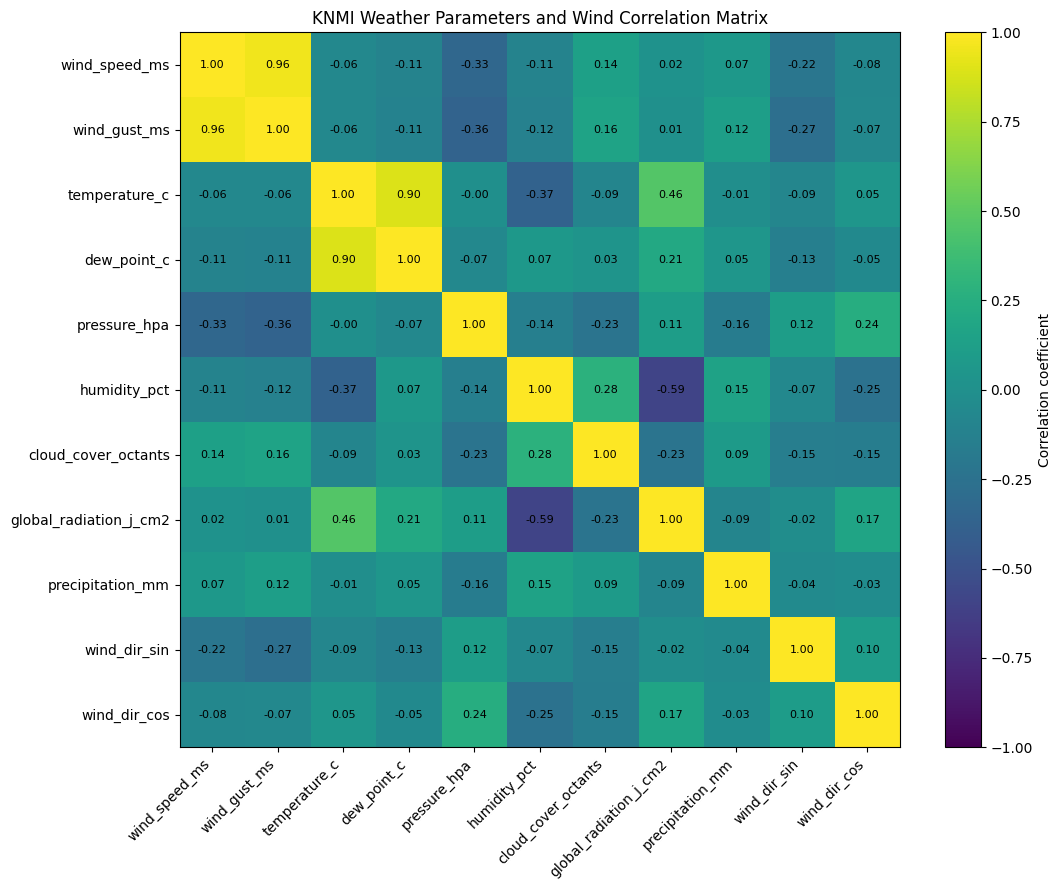

Saved figure: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\figures\PB2_KNMI\knmi_correlation_heatmap.png


In [33]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation coefficient")
ax.set_title("KNMI Weather Parameters and Wind Correlation Matrix")
plt.tight_layout()

heatmap_path = FIGURE_DIR / "knmi_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=200)
plt.show()

print("Saved figure:", heatmap_path)

## 13. Graph 2: Wind speed vs temperature

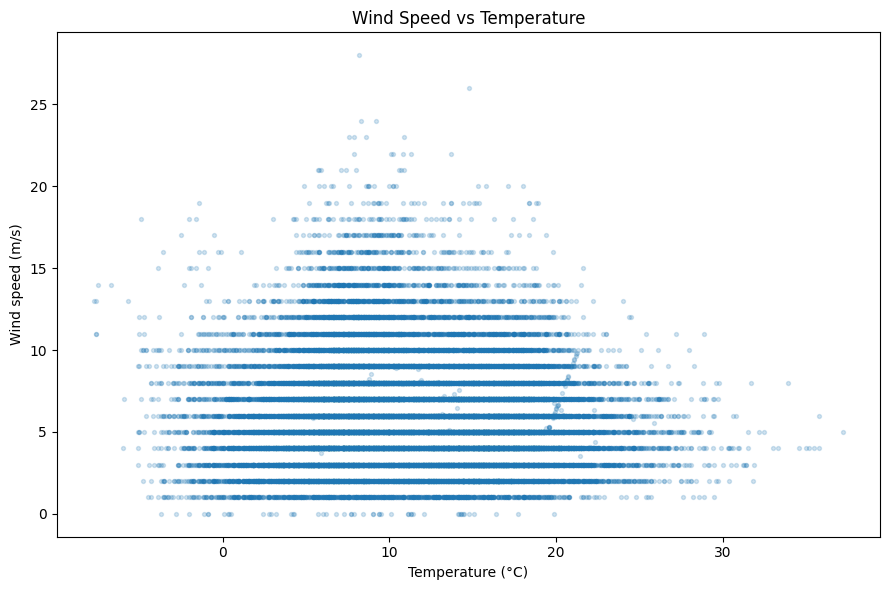

Saved figure: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\figures\PB2_KNMI\wind_speed_vs_temperature.png


In [34]:
plot_data = final_knmi.dropna(subset=["wind_speed_ms", "temperature_c"])
plot_sample = plot_data.sample(min(30000, len(plot_data)), random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(plot_sample["temperature_c"], plot_sample["wind_speed_ms"], alpha=0.2, s=8)
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind speed (m/s)")
plt.title("Wind Speed vs Temperature")
plt.tight_layout()

temp_path = FIGURE_DIR / "wind_speed_vs_temperature.png"
plt.savefig(temp_path, dpi=200)
plt.show()

print("Saved figure:", temp_path)

## 14. Graph 3: Wind speed vs air pressure

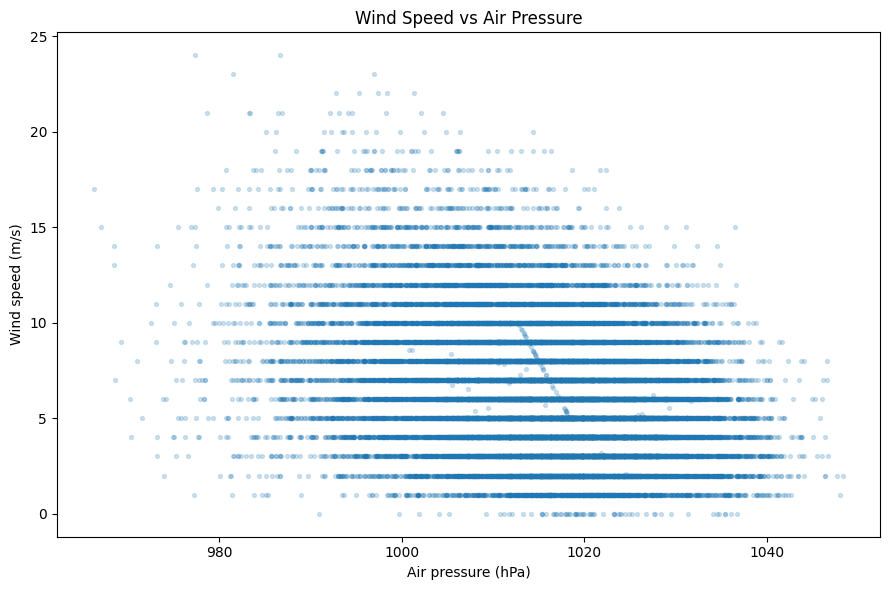

Saved figure: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\figures\PB2_KNMI\wind_speed_vs_pressure.png


In [35]:
plot_data = final_knmi.dropna(subset=["wind_speed_ms", "pressure_hpa"])
plot_sample = plot_data.sample(min(30000, len(plot_data)), random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(plot_sample["pressure_hpa"], plot_sample["wind_speed_ms"], alpha=0.2, s=8)
plt.xlabel("Air pressure (hPa)")
plt.ylabel("Wind speed (m/s)")
plt.title("Wind Speed vs Air Pressure")
plt.tight_layout()

pressure_path = FIGURE_DIR / "wind_speed_vs_pressure.png"
plt.savefig(pressure_path, dpi=200)
plt.show()

print("Saved figure:", pressure_path)

## 15. Graph 4: Wind speed by cloud cover

Cloud cover is measured in octants. A value of 0 means clear sky, while 8 means fully covered. A value of 9 means the sky is invisible.

C:\Users\ralph\AppData\Local\Temp\ipykernel_25704\2107369570.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


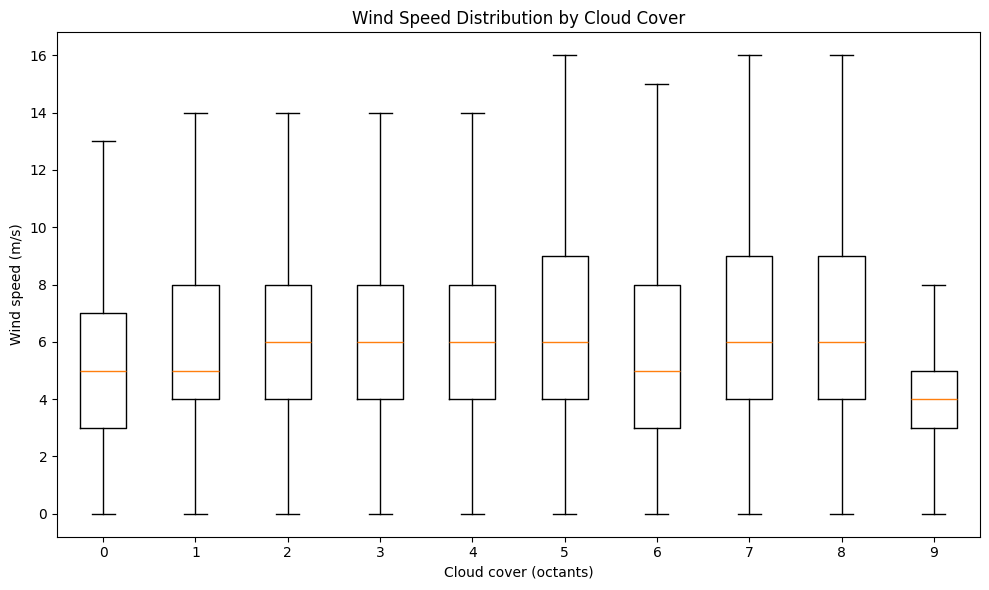

Saved figure: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\figures\PB2_KNMI\wind_speed_by_cloud_cover_boxplot.png


In [36]:
if "cloud_cover_octants" in final_knmi.columns:
    box_data = final_knmi.dropna(subset=["wind_speed_ms", "cloud_cover_octants"]).copy()
    box_data["cloud_cover_octants"] = box_data["cloud_cover_octants"].round().astype(int)

    groups = []
    labels = []
    for cloud_value in sorted(box_data["cloud_cover_octants"].unique()):
        values = box_data.loc[box_data["cloud_cover_octants"] == cloud_value, "wind_speed_ms"].dropna()
        if len(values) > 0:
            groups.append(values.sample(min(5000, len(values)), random_state=42))
            labels.append(str(cloud_value))

    plt.figure(figsize=(10, 6))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.xlabel("Cloud cover (octants)")
    plt.ylabel("Wind speed (m/s)")
    plt.title("Wind Speed Distribution by Cloud Cover")
    plt.tight_layout()

    cloud_path = FIGURE_DIR / "wind_speed_by_cloud_cover_boxplot.png"
    plt.savefig(cloud_path, dpi=200)
    plt.show()

    print("Saved figure:", cloud_path)
else:
    print("cloud_cover_octants column is not available.")

## 16. Graph 5: Monthly average wind speed by station

This graph is useful for checking whether the merged station datasets look sensible after combining the split year files.

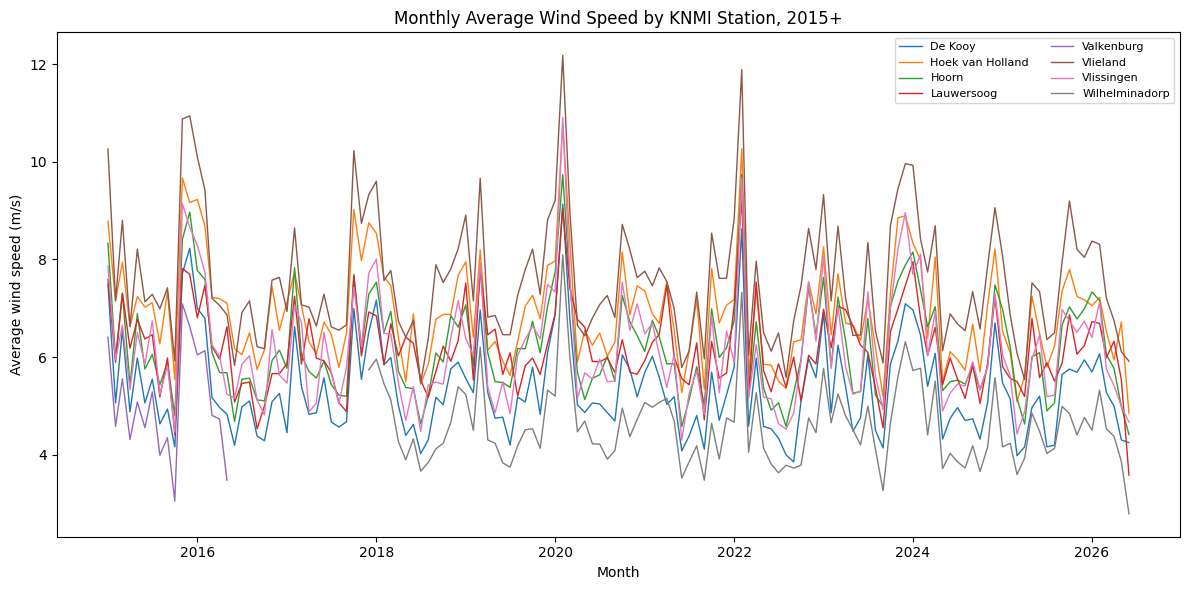

Saved figure: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (1)\Offshore_Wind_Energy_Forecasting-main\figures\PB2_KNMI\monthly_average_wind_speed_by_station.png


In [37]:
monthly = final_knmi.copy()
monthly["month"] = monthly["timestamp"].dt.to_period("M").dt.to_timestamp()
monthly_avg = monthly.groupby(["month", "Station"], as_index=False)["wind_speed_ms"].mean()

plt.figure(figsize=(12, 6))
for station, group in monthly_avg.groupby("Station"):
    plt.plot(group["month"], group["wind_speed_ms"], label=station, linewidth=1)

plt.xlabel("Month")
plt.ylabel("Average wind speed (m/s)")
plt.title("Monthly Average Wind Speed by KNMI Station, 2015+")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()

monthly_path = FIGURE_DIR / "monthly_average_wind_speed_by_station.png"
plt.savefig(monthly_path, dpi=200)
plt.show()

print("Saved figure:", monthly_path)

## 17. Strongest correlations with wind speed

This table helps with the written explanation for PB2-02.

In [38]:
if "wind_speed_ms" in corr.columns:
    strongest = (
        corr["wind_speed_ms"]
        .drop("wind_speed_ms")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .reset_index()
    )
    strongest.columns = ["variable", "correlation_with_wind_speed"]
    display(strongest)

    strongest.to_csv(OUTPUT_DIR / "knmi_strongest_correlations_with_wind_speed.csv", index=False)
    print("Saved strongest correlation table")
else:
    print("wind_speed_ms not available in correlation matrix.")

,variable,correlation_with_wind_speed
0,wind_gust_ms,0.955577
1,pressure_hpa,-0.333204
2,wind_dir_sin,-0.218710
3,cloud_cover_octants,0.139040
4,dew_point_c,-0.107127
5,humidity_pct,-0.105596
6,wind_dir_cos,-0.076766
7,precipitation_mm,0.068746
8,temperature_c,-0.063407
9,global_radiation_j_cm2,0.018428


Saved strongest correlation table


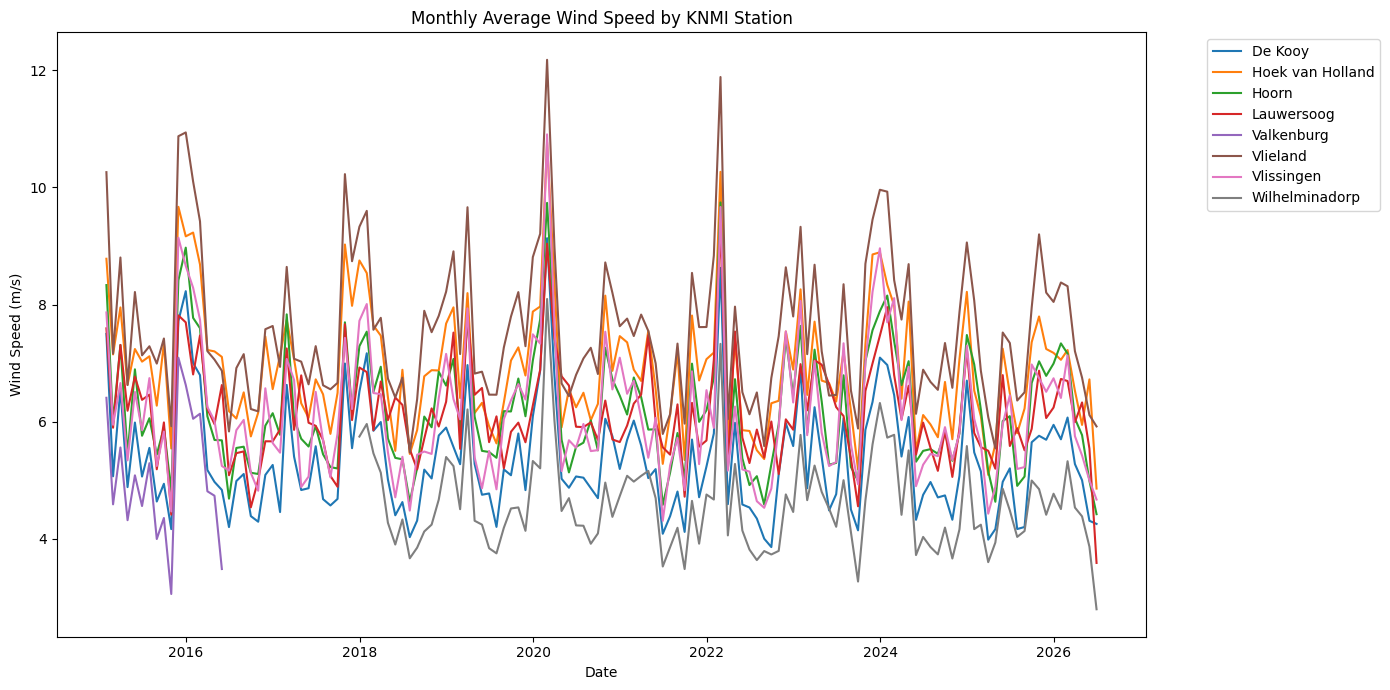

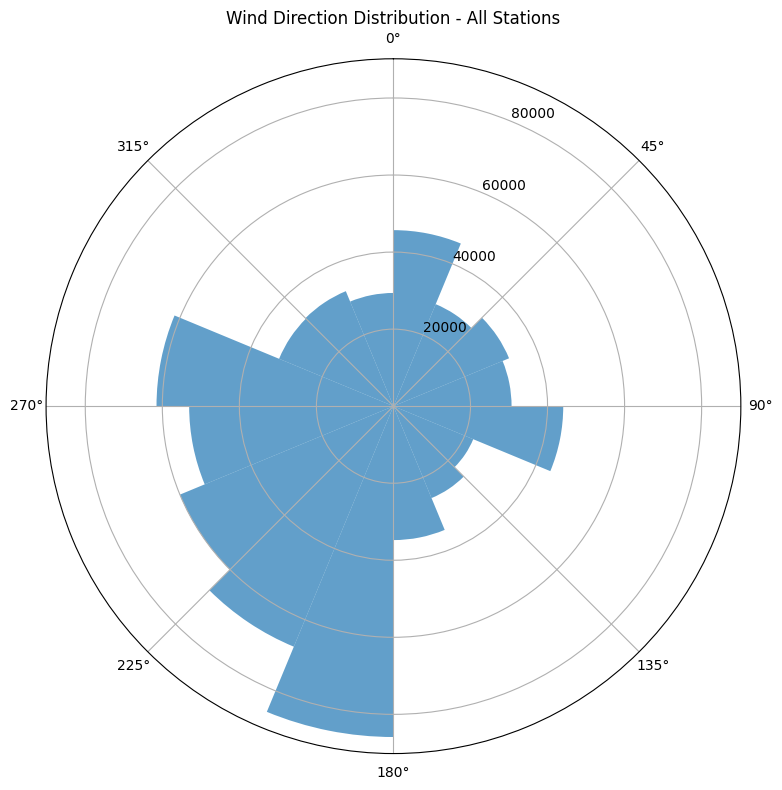

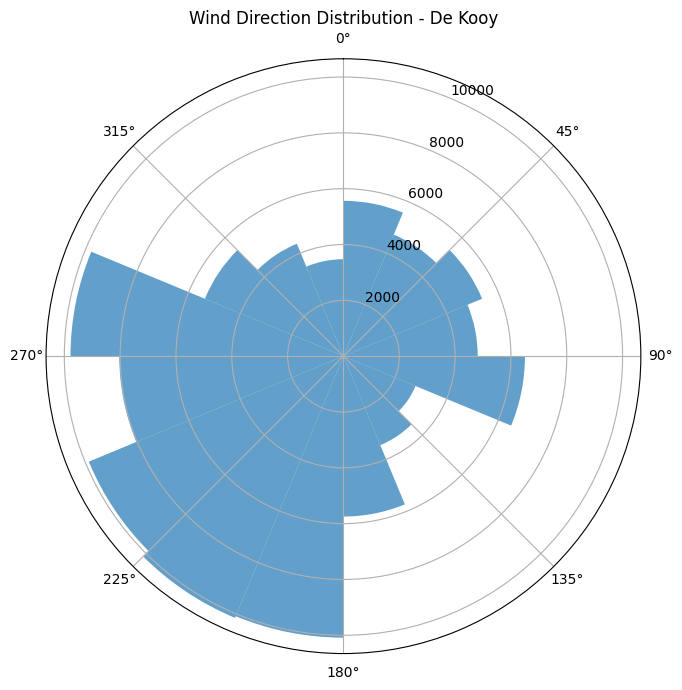

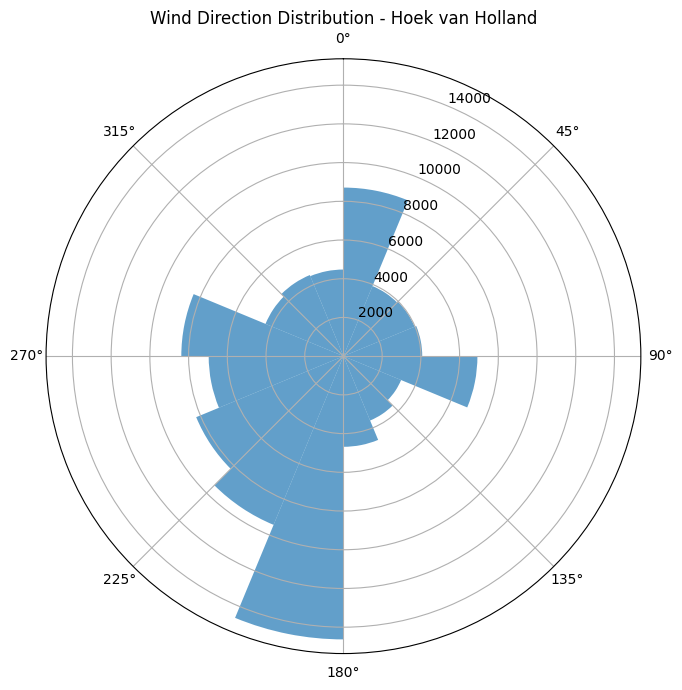

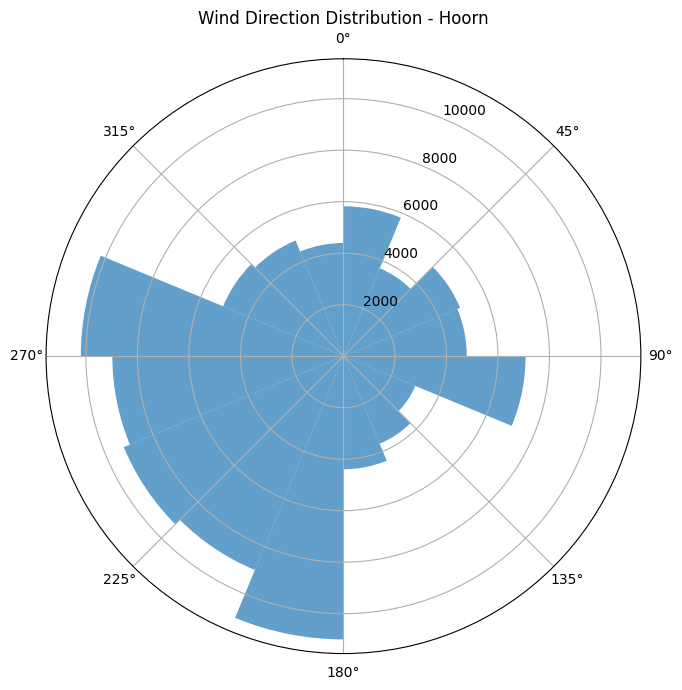

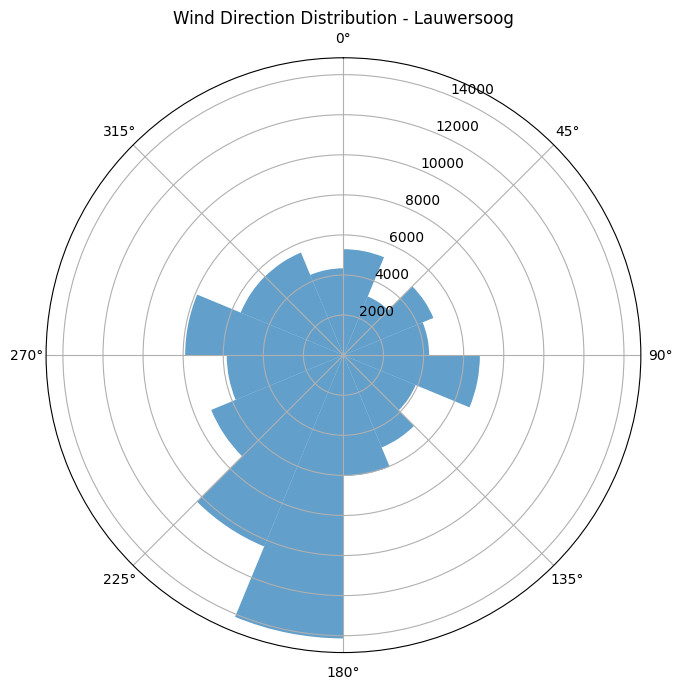

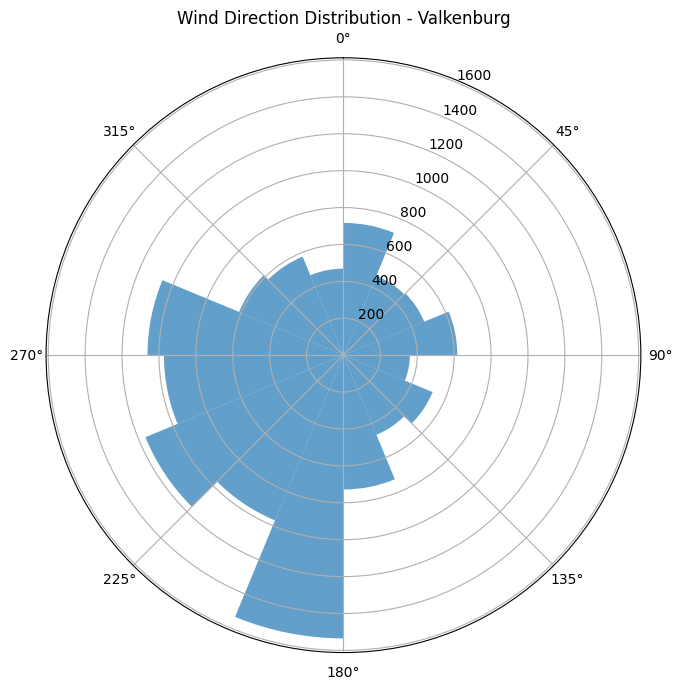

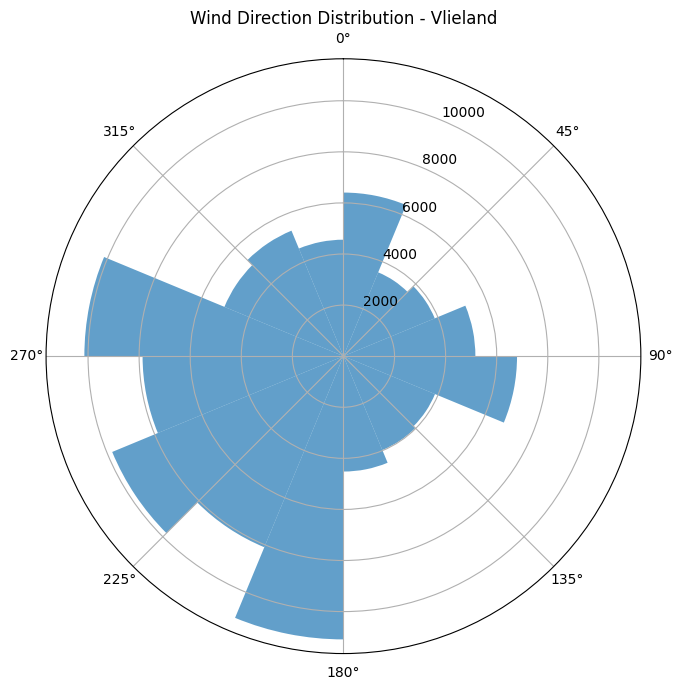

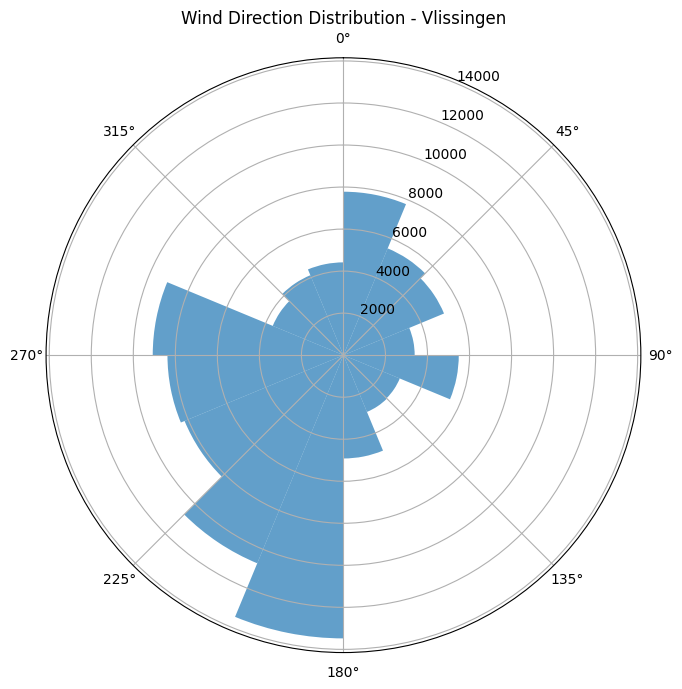

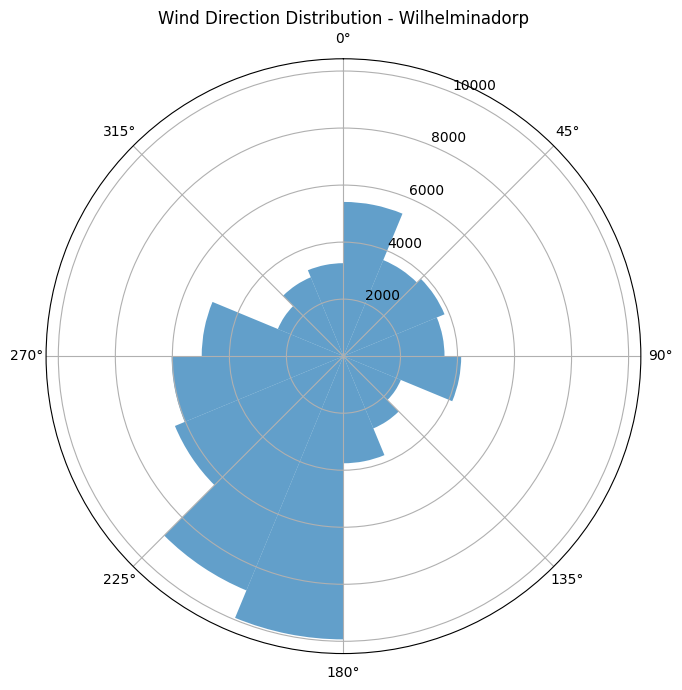

Visualisations completed successfully.


In [39]:
# ==========================================
# PB2-02 VISUALISATIONS
# Wind speed line plot + wind direction polar plots
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = knmi_preprocessed.copy()

station_col = "Station"
wind_speed_col = "wind_speed_ms"
wind_direction_col = "wind_direction_interpolated_deg"

df["timestamp"] = pd.to_datetime(df["timestamp"])
df[wind_speed_col] = pd.to_numeric(df[wind_speed_col], errors="coerce")
df[wind_direction_col] = pd.to_numeric(df[wind_direction_col], errors="coerce")

# ==========================================
# Monthly average wind speed by station
# ==========================================

monthly_wind = (
    df
    .set_index("timestamp")
    .groupby(station_col)[wind_speed_col]
    .resample("ME")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for station in monthly_wind[station_col].unique():
    station_data = monthly_wind[monthly_wind[station_col] == station]

    plt.plot(
        station_data["timestamp"],
        station_data[wind_speed_col],
        linewidth=1.5,
        label=str(station)
    )

plt.title("Monthly Average Wind Speed by KNMI Station")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_average_wind_speed_by_station.png",
    dpi=300
)

plt.show()


# ==========================================
# Wind direction polar plot - all stations
# ==========================================

wind_dir = df[[wind_direction_col]].dropna()

wind_dir = wind_dir[
    (wind_dir[wind_direction_col] >= 0)
    &
    (wind_dir[wind_direction_col] <= 360)
]

angles = np.deg2rad(wind_dir[wind_direction_col])

bins = np.linspace(0, 2 * np.pi, 17)
counts, edges = np.histogram(angles, bins=bins)

width = edges[1] - edges[0]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(
    edges[:-1],
    counts,
    width=width,
    align="edge",
    alpha=0.7
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_title("Wind Direction Distribution - All Stations")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_direction_distribution_all_stations.png",
    dpi=300
)

plt.show()


# ==========================================
# Wind direction polar plots per station
# ==========================================

stations = sorted(df[station_col].dropna().unique())

for station in stations:
    station_data = df[df[station_col] == station][[wind_direction_col]].dropna()

    station_data = station_data[
        (station_data[wind_direction_col] >= 0)
        &
        (station_data[wind_direction_col] <= 360)
    ]

    if station_data.empty:
        continue

    angles = np.deg2rad(station_data[wind_direction_col])

    bins = np.linspace(0, 2 * np.pi, 17)
    counts, edges = np.histogram(angles, bins=bins)

    width = edges[1] - edges[0]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    ax.bar(
        edges[:-1],
        counts,
        width=width,
        align="edge",
        alpha=0.7
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(f"Wind Direction Distribution - {station}")

    safe_name = str(station).replace(" ", "_").replace("/", "_")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"wind_direction_distribution_{safe_name}.png",
        dpi=300
    )

    plt.show()

print("Visualisations completed successfully.")

## 18. Short report text for the backlog

You can paste/adapt this in your sprint documentation.

In [40]:
report_text = f"""
For PB2-01, the KNMI hourly weather files were loaded from the raw KNMI dataset folder and combined into one dataset. Files belonging to the same weather station but different time periods were merged using the station number and timestamp. The dataset was then trimmed so that only observations from 2015 onward were kept. KNMI units were standardized: wind speed and gusts were converted from 0.1 m/s to m/s, temperature and dew point from 0.1°C to °C, pressure from 0.1 hPa to hPa, rainfall from 0.1 mm to mm, and sunshine/precipitation duration from 0.1 hours to hours. KNMI special values such as trace precipitation and trace sunshine were converted to zero, while variable wind direction was treated as missing.

Missing values were handled according to variable type. Continuous weather variables such as wind speed, temperature, dew point, pressure, humidity, radiation and visibility were interpolated over time within each station. Wind direction was converted into sine and cosine components before interpolation because wind direction is circular. Cloud cover was forward/backward filled and rounded because it is a discrete octant value. Precipitation values were filled with zero after KNMI trace precipitation values had already been cleaned.

For PB2-02, a correlation matrix was created using wind speed, gust speed, temperature, dew point, air pressure, humidity, cloud cover, global radiation, precipitation and wind direction components. Additional visualizations were produced, including wind speed against temperature, wind speed against air pressure, wind speed grouped by cloud cover, and monthly average wind speed by station. These outputs can be used to identify which weather variables have the strongest relationship with wind speed and to support the forecasting feature selection process.
"""
# Check what dataframe exists
